Module 8 Case study 2

In [40]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
#1 We shall use the same dataset used in the previous assignment -digits.
# Make an 80-20 train/test split.
# [Hint:Explore datasets module from scikit learn]

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
#2 Using scikit learn to perform an LDA on the dataset. 
# Find out the number of components in the projected subspace.
# [Hint:Refer to a discriminant analysis module of scikit learn]

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

ypred = lda.predict(X_test)
score = accuracy_score(y_test, ypred)
print(f'Accuracy score: {score: .2f}')

# LDA also takes no. of classes in y/target variable into account, min(n_classes-1,n_features)
print('Feature count in original dataset:', X.shape[1])
print('No. of classes in target variable:', digits.target_names.shape[0])
print('No. of components in projected subspace:', lda.explained_variance_ratio_.shape[0])

Accuracy score:  0.94
Feature count in original dataset: 64
No. of classes in target variable: 10
No. of components in projected subspace: 9


In [28]:
# LDA concept

nclasses = digits.target_names.shape[0] 
nfeatures = len(digits.feature_names)    
print('nclasses =', nclasses, ',', 'nfeatures =', nfeatures)
print('Components in LDA:', min(nclasses-1, nfeatures))

nclasses = 10 , nfeatures = 64
Components in LDA: 9


In [34]:
#3 Transform the dataset and fit a logistic regression and observe the accuracy. 
# Compare it with the previous model based on PCA in terms of accuracy and model complexity.
# [Hint: Project both the train and test samples to the new subspace]

# Transform the dataset
X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

regr = LogisticRegression()
regr.fit(X_train_lda, y_train)

ypred2 = regr.predict(X_test_lda)

score2 = accuracy_score(y_test, ypred2)
print(f'Accuracy score of Logreg on transformed dataset: {score2: .2f}')

Accuracy score of Logreg on transformed dataset:  0.97


In [50]:
# comparing with previous PCA model

print('Accuracy: \nBoth models have an accuracy of 97%\n')
print('Model complexity(no. of components): \nLDA - 9, PCA - 40\n\n')

print('LDA is a better model as it suits the classification of digits')

Accuracy: 
Both models have an accuracy of 97%

Model complexity(no. of components): 
LDA - 9, PCA - 40


LDA is a better model as it suits the classification of digits


Previous PCA model accuracy (attached images)

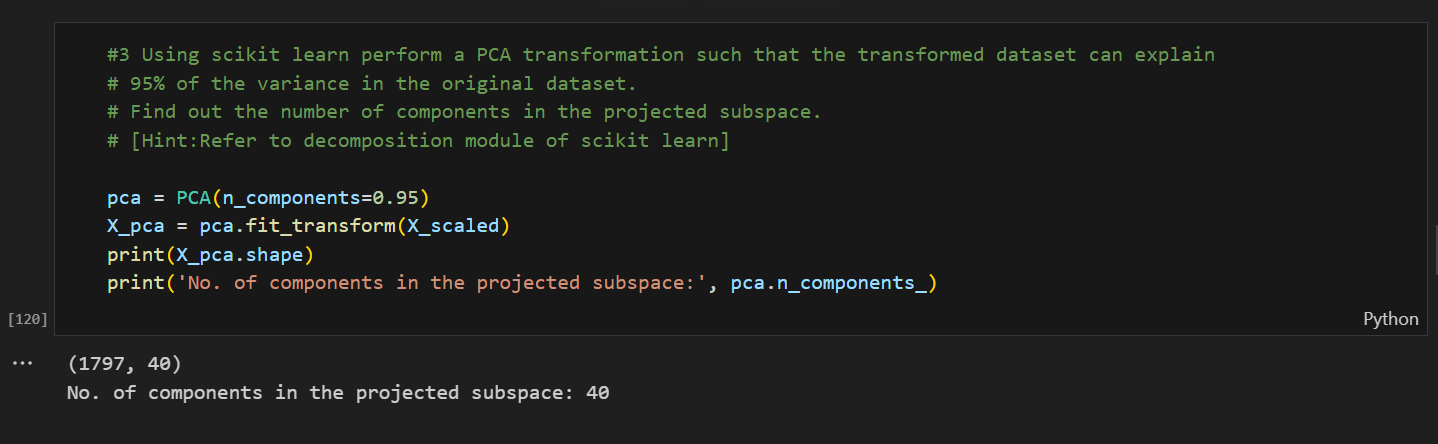

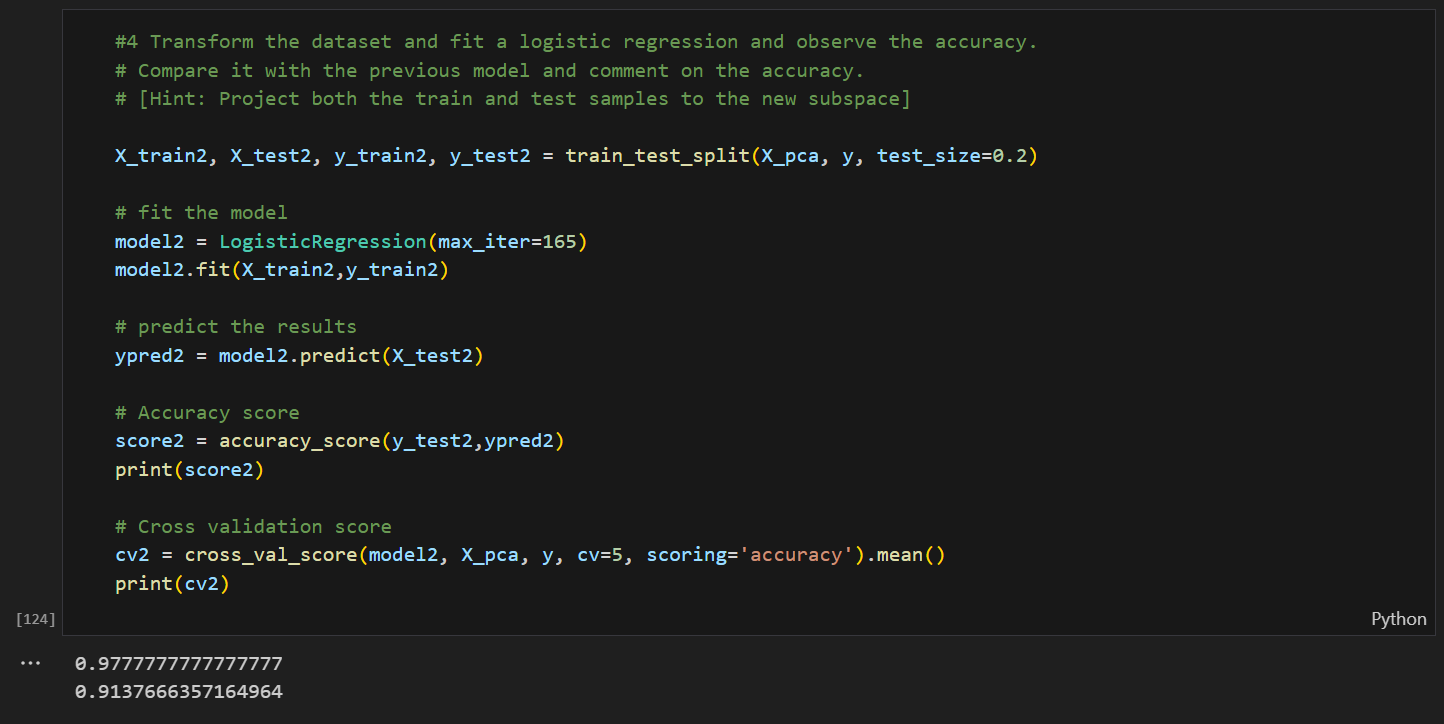

In [48]:
# confusion matrix of LDA untransformed vs transformed model

cm1 = confusion_matrix(y_test, ypred)   # untransformed predictors
cm2 = confusion_matrix(y_test, ypred2)  # transformed predictors 

print(cm1.sum() - cm1.trace())
print(cm2.sum() - cm2.trace())

20
12
